# 05 - Spectrometer Resolution, Calibration, and Peak Fitting

This notebook models a compact spectrometer workflow: grating geometry,
wavelength calibration, line-spread function, detector noise, baseline
subtraction, peak fitting, uncertainty, and resolving close spectral lines.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import plotting

plotting.set_style()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from src.detector import grating_diffraction_angle, gaussian_peak, lorentzian_peak, resolving_power

## 1. Engineering Problem

Build a calibration and fitting workflow that turns detector pixels into
wavelengths and reports peak centers with uncertainty. The practical questions:

- What spectral range and resolution does the grating geometry allow?
- How accurately can calibration lines map pixel to wavelength?
- Does Gaussian, Lorentzian, or Voigt peak fitting change the reported center?
- When do two close lines become unresolved?
- How does slit width trade resolution against throughput and SNR?

## 2. Physical Assumptions

- Grating equation: `m lambda = d(sin alpha + sin beta)`.
- The pixel-to-wavelength map is locally polynomial after optical alignment.
- The line-spread function is approximated by Gaussian, Lorentzian, or Voigt
  profiles depending on the dominant broadening mechanism.
- Detector noise combines shot/read noise and a slowly varying baseline.
- Peak-parameter covariance from nonlinear least squares is used as a local
  uncertainty estimate.

## 3. System Parameters

In [2]:
groove_density = 1_200e3  # lines/m
incidence_angle = np.deg2rad(12.0)
order = 1
pixel_count = 2048
true_coeff = np.array([1.2e-6, 0.115, 520.0])  # nm = a2*x^2 + a1*x + a0
fwhm_nm = 0.35
read_noise_counts = 8.0

pd.DataFrame(
    [
        ("groove_density", groove_density, "lines/m", "Grating groove density; sets angular dispersion."),
        ("incidence_angle", np.rad2deg(incidence_angle), "deg", "Input angle in grating equation."),
        ("order", order, "integer", "Diffraction order."),
        ("pixel_count", pixel_count, "pixels", "Linear detector size."),
        ("calibration_polynomial", "quadratic", "nm(pixel)", "Maps detector pixel to wavelength."),
        ("fwhm_nm", fwhm_nm, "nm", "Instrument line-spread FWHM."),
        ("read_noise_counts", read_noise_counts, "counts RMS", "Detector/electronics read noise."),
    ],
    columns=["parameter", "value", "unit", "engineering meaning"],
)

,parameter,value,unit,engineering meaning
0,groove_density,1200000.0,lines/m,Grating groove density; sets angular dispersion.
1,incidence_angle,12.0,deg,Input angle in grating equation.
2,order,1,integer,Diffraction order.
3,pixel_count,2048,pixels,Linear detector size.
4,calibration_polynomial,quadratic,nm(pixel),Maps detector pixel to wavelength.
5,fwhm_nm,0.35,nm,Instrument line-spread FWHM.
6,read_noise_counts,8.0,counts RMS,Detector/electronics read noise.


## 4. Simulation Model

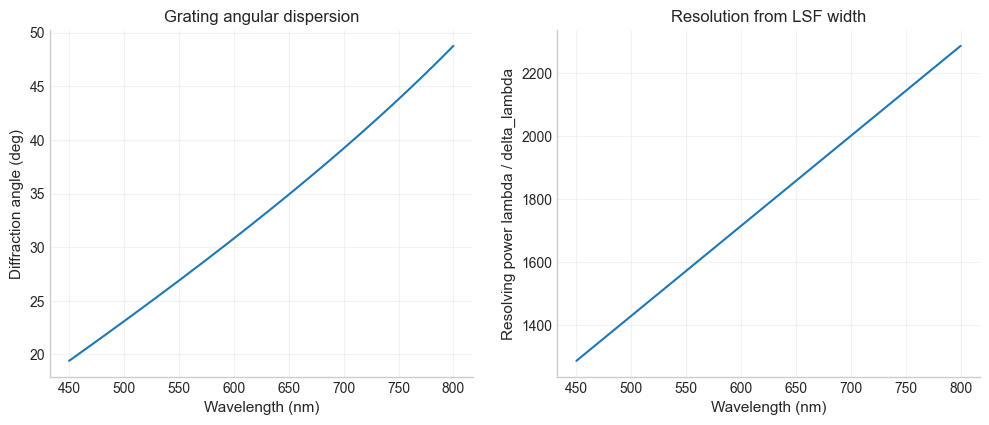

In [3]:
wavelengths_nm = np.linspace(450, 800, 300)
angles_deg = np.rad2deg(grating_diffraction_angle(wavelengths_nm * 1e-9, groove_density, incidence_angle, order))
res_power = resolving_power(wavelengths_nm, fwhm_nm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(wavelengths_nm, angles_deg)
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Diffraction angle (deg)")
axes[0].set_title("Grating angular dispersion")
axes[1].plot(wavelengths_nm, res_power)
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Resolving power lambda / delta_lambda")
axes[1].set_title("Resolution from LSF width")
plt.show()

In [4]:
rng = np.random.default_rng(12)
cal_pixels = np.array([120, 380, 760, 1100, 1450, 1780, 1980])
cal_wavelengths_true = np.polyval(true_coeff, cal_pixels)
cal_wavelengths_measured = cal_wavelengths_true + rng.normal(0, 0.03, len(cal_pixels))
fit_coeff = np.polyfit(cal_pixels, cal_wavelengths_measured, deg=2)
pixel_axis = np.arange(pixel_count)
wavelength_axis = np.polyval(fit_coeff, pixel_axis)
cal_residual_pm = (np.polyval(fit_coeff, cal_pixels) - cal_wavelengths_true) * 1e3

pd.DataFrame(
    {
        "pixel": cal_pixels,
        "true_wavelength_nm": cal_wavelengths_true,
        "measured_line_nm": cal_wavelengths_measured,
        "fit_residual_pm": cal_residual_pm,
    }
)

,pixel,true_wavelength_nm,measured_line_nm,fit_residual_pm
0,120,533.81728,533.817075,3.056586
1,380,563.87328,563.904664,20.546107
2,760,608.09312,608.115368,33.257384
3,1100,647.95200,647.973719,31.695761
4,1450,689.27300,689.321563,17.327703
5,1780,728.50208,728.465913,-8.076289
6,1980,752.40448,752.385671,-29.073531


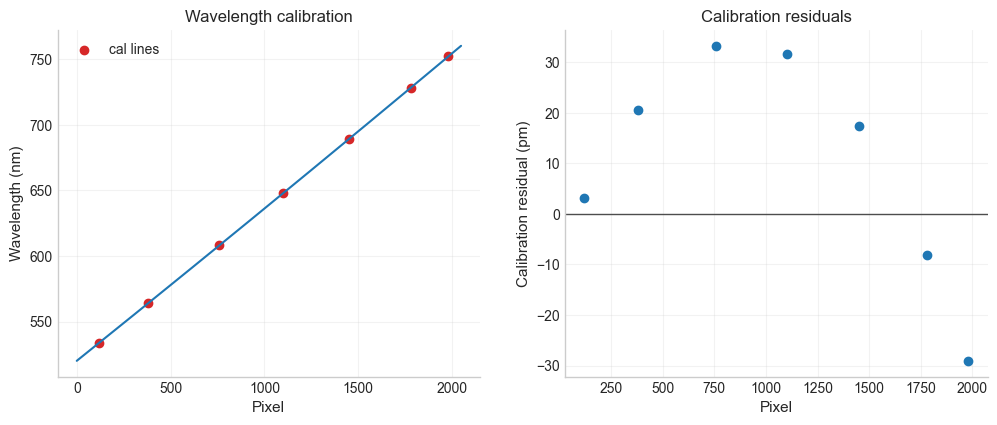

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(pixel_axis, wavelength_axis)
axes[0].scatter(cal_pixels, cal_wavelengths_measured, color="tab:red", label="cal lines")
axes[0].set_xlabel("Pixel")
axes[0].set_ylabel("Wavelength (nm)")
axes[0].set_title("Wavelength calibration")
axes[0].legend()
axes[1].axhline(0, color="0.3", lw=1)
axes[1].scatter(cal_pixels, cal_residual_pm)
axes[1].set_xlabel("Pixel")
axes[1].set_ylabel("Calibration residual (pm)")
axes[1].set_title("Calibration residuals")
plt.show()

## 5. Noise / Uncertainty Model

In [6]:
def gaussian_model(x, amplitude, center, sigma, baseline0, baseline1):
    return baseline0 + baseline1 * (x - x.mean()) + amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)

def lorentzian_model(x, amplitude, center, gamma, baseline0, baseline1):
    return baseline0 + baseline1 * (x - x.mean()) + amplitude * gamma**2 / ((x - center) ** 2 + gamma**2)

def voigt_model(x, amplitude, center, sigma, gamma, baseline0, baseline1):
    profile = voigt_profile(x - center, sigma, gamma)
    profile = profile / profile.max()
    return baseline0 + baseline1 * (x - x.mean()) + amplitude * profile

x_nm = np.linspace(630, 638, 900)
true_center_nm = 633.42
sigma_nm = fwhm_nm / 2.355
baseline = 120 + 1.5 * (x_nm - x_nm.mean())
clean = baseline + 2200 * np.exp(-0.5 * ((x_nm - true_center_nm) / sigma_nm) ** 2)
noisy = rng.poisson(np.maximum(clean, 0)) + rng.normal(0, read_noise_counts, len(x_nm))

popt_g, pcov_g = curve_fit(gaussian_model, x_nm, noisy, p0=[2000, 633.4, 0.15, 120, 0])
popt_l, pcov_l = curve_fit(lorentzian_model, x_nm, noisy, p0=[2000, 633.4, 0.15, 120, 0])
popt_v, pcov_v = curve_fit(voigt_model, x_nm, noisy, p0=[2000, 633.4, 0.12, 0.08, 120, 0])

fit_summary = pd.DataFrame(
    [
        ("Gaussian", popt_g[1], np.sqrt(pcov_g[1, 1]) * 1e3),
        ("Lorentzian", popt_l[1], np.sqrt(pcov_l[1, 1]) * 1e3),
        ("Voigt", popt_v[1], np.sqrt(pcov_v[1, 1]) * 1e3),
    ],
    columns=["model", "fitted_center_nm", "center_uncertainty_pm"],
)
fit_summary

,model,fitted_center_nm,center_uncertainty_pm
0,Gaussian,633.421002,0.305643
1,Lorentzian,633.421327,1.049224
2,Voigt,633.421002,0.305809


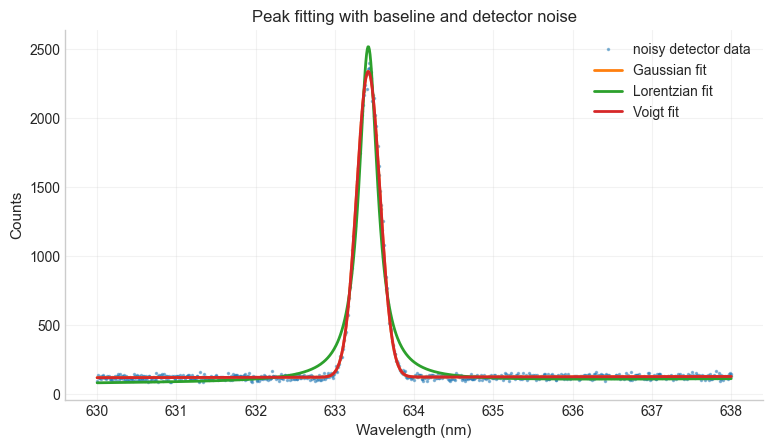

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x_nm, noisy, ".", ms=3, alpha=0.45, label="noisy detector data")
ax.plot(x_nm, gaussian_model(x_nm, *popt_g), lw=2, label="Gaussian fit")
ax.plot(x_nm, lorentzian_model(x_nm, *popt_l), lw=2, label="Lorentzian fit")
ax.plot(x_nm, voigt_model(x_nm, *popt_v), lw=2, label="Voigt fit")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Counts")
ax.set_title("Peak fitting with baseline and detector noise")
ax.legend()
plt.show()

## 6. Parameter Scan

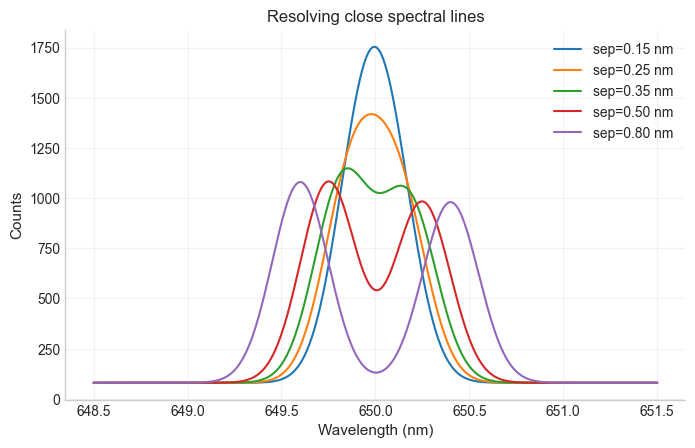

In [8]:
def two_line_spectrum(x, separation_nm, fwhm):
    sigma = fwhm / 2.355
    c0 = 650.0
    return (
        gaussian_peak(x, 1000, c0 - separation_nm / 2, sigma, 0)
        + gaussian_peak(x, 900, c0 + separation_nm / 2, sigma, 0)
        + 80
    )

sep_values = [0.15, 0.25, 0.35, 0.50, 0.80]
x2 = np.linspace(648.5, 651.5, 800)

fig, ax = plt.subplots()
for sep in sep_values:
    ax.plot(x2, two_line_spectrum(x2, sep, fwhm_nm), label=f"sep={sep:.2f} nm")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Counts")
ax.set_title("Resolving close spectral lines")
ax.legend()
plt.show()

## 7. Failure Regime

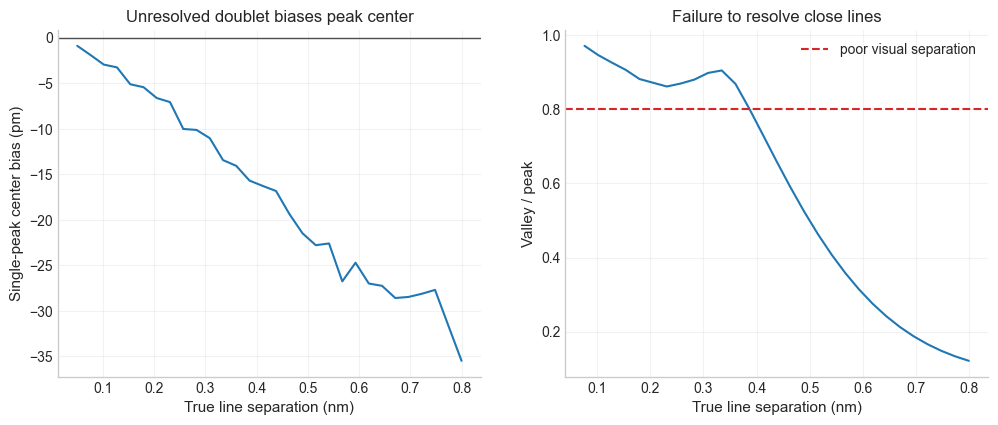

In [9]:
def single_gaussian_with_baseline(x, amplitude, center, sigma, baseline):
    return gaussian_peak(x, amplitude, center, sigma, baseline)

failure_rows = []
for sep in np.linspace(0.05, 0.8, 30):
    y_clean = two_line_spectrum(x2, sep, fwhm_nm)
    y_obs = rng.poisson(np.maximum(y_clean, 0)) + rng.normal(0, read_noise_counts, len(x2))
    popt, _ = curve_fit(
        single_gaussian_with_baseline,
        x2,
        y_obs,
        p0=[1800, 650, sigma_nm, 80],
        bounds=([0, 649.0, 1e-3, 0], [np.inf, 651.0, 1.0, np.inf]),
        maxfev=5000,
    )
    valley = np.min(y_clean[(x2 > 650 - sep / 2) & (x2 < 650 + sep / 2)]) if sep > 0.06 else np.nan
    peak = np.max(y_clean)
    failure_rows.append((sep, popt[1] - 650.0, valley / peak if np.isfinite(valley) else np.nan))

failure = pd.DataFrame(failure_rows, columns=["true_separation_nm", "single_peak_center_bias_nm", "valley_to_peak_ratio"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(failure["true_separation_nm"], failure["single_peak_center_bias_nm"] * 1e3)
axes[0].axhline(0, color="0.3", lw=1)
axes[0].set_xlabel("True line separation (nm)")
axes[0].set_ylabel("Single-peak center bias (pm)")
axes[0].set_title("Unresolved doublet biases peak center")
axes[1].plot(failure["true_separation_nm"], failure["valley_to_peak_ratio"])
axes[1].axhline(0.8, color="tab:red", ls="--", label="poor visual separation")
axes[1].set_xlabel("True line separation (nm)")
axes[1].set_ylabel("Valley / peak")
axes[1].set_title("Failure to resolve close lines")
axes[1].legend()
plt.show()

## 8. Design Trade-Off

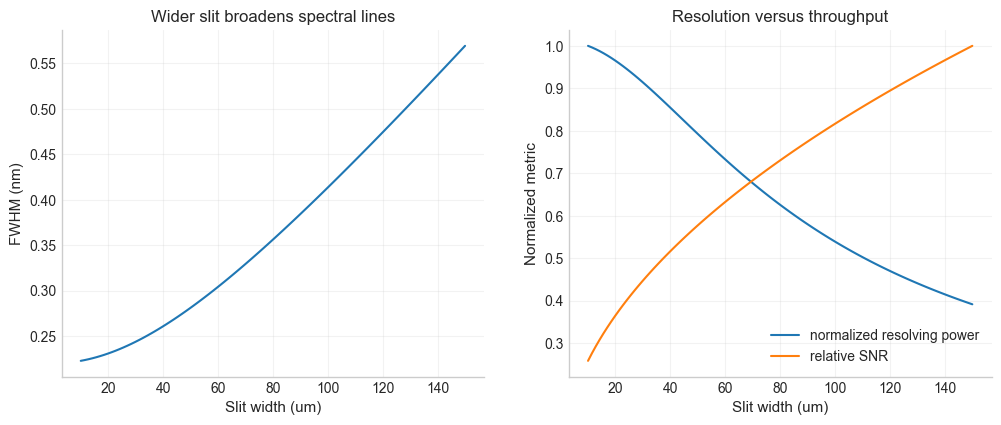

In [10]:
slit_width_um = np.linspace(10, 150, 100)
base_fwhm_nm = 0.22
slit_broadening_nm = 0.0035 * slit_width_um
effective_fwhm = np.sqrt(base_fwhm_nm**2 + slit_broadening_nm**2)
throughput = slit_width_um / slit_width_um.max()
relative_snr = np.sqrt(throughput)
resolution = resolving_power(650, effective_fwhm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(slit_width_um, effective_fwhm, label="FWHM")
axes[0].set_xlabel("Slit width (um)")
axes[0].set_ylabel("FWHM (nm)")
axes[0].set_title("Wider slit broadens spectral lines")
axes[1].plot(slit_width_um, resolution / resolution.max(), label="normalized resolving power")
axes[1].plot(slit_width_um, relative_snr, label="relative SNR")
axes[1].set_xlabel("Slit width (um)")
axes[1].set_ylabel("Normalized metric")
axes[1].set_title("Resolution versus throughput")
axes[1].legend()
plt.show()

## 9. Key Engineering Conclusions

- A spectrometer project should report both calibration residuals and peak-fit
  uncertainty; a fitted center without uncertainty is incomplete.
- The line-spread function matters: Gaussian, Lorentzian, and Voigt fits can give
  different centers and widths when the model is mismatched.
- Polynomial calibration is reliable inside the calibrated pixel range but can
  fail badly when extrapolated.
- Two close lines become a metrology failure before they become visually obvious;
  unresolved doublets can bias the reported center.
- Narrower slits improve resolution but reduce throughput and SNR, while wider
  slits improve signal at the cost of spectral resolving power.
- For industrial spectroscopy, the useful output is not just a plot; it is a
  calibrated wavelength axis, residuals, fit parameters, uncertainty, and a clear
  statement of the resolution limit.